In [1]:
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns
df = pd.read_csv("cleaned_data.csv", parse_dates=["Order Date", "Ship Date"])

cust = df.groupby(["Customer ID", "Customer Name"]).agg(
    total_sales=("Sales", "sum"),
    orders=("Order ID", "nunique")).reset_index()
cust["avg_order_value"] = cust["total_sales"] / cust["orders"]
print(cust.sort_values("total_sales", ascending=False).head(10))

    Customer ID       Customer Name  total_sales  orders  avg_order_value
700    SM-20320         Sean Miller    25043.050       5      5008.610000
741    TC-20980        Tamara Chand    19052.218       5      3810.443600
621    RB-19360        Raymond Buch    15117.339       6      2519.556500
730    TA-21385        Tom Ashbrook    14595.620       4      3648.905000
6      AB-10105       Adrian Barton    14473.571      10      1447.357100
434    KL-16645        Ken Lonsdale    14175.229      12      1181.269083
669    SC-20095        Sanjit Chand    14142.334       9      1571.370444
327    HL-15040        Hunter Lopez    12873.298       6      2145.549667
683    SE-20110        Sanjit Engle    12209.438      11      1109.948909
131    CC-12370  Christopher Conant    12129.072       5      2425.814400


In [2]:
cust["Group"] = pd.qcut(cust["total_sales"], 3, labels=["Low", "Medium", "High"])
print(cust.groupby("Group").agg(customers=("Customer ID", "count"),
      avg_sales=("total_sales", "mean"), avg_orders=("orders", "mean")))

top20 = cust.sort_values("total_sales", ascending=False).head(int(len(cust)*0.2))
print("Top 20% customers' share of sales:", round(top20["total_sales"].sum()/cust["total_sales"].sum()*100, 1), "%")

        customers    avg_sales  avg_orders
Group                                     
Low           264   772.334424    4.454545
Medium        264  2210.649772    6.484848
High          265  5562.373415    7.675472
Top 20% customers' share of sales: 48.3 %


/tmp/ipykernel_3388/1196692752.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(cust.groupby("Group").agg(customers=("Customer ID", "count"),


In [3]:
print(df.groupby("State")["Sales"].sum().sort_values(ascending=False).head(10))
print(pd.pivot_table(df, values="Sales", index="Segment", columns="Region", aggfunc="sum").round(0))
high_ids = cust[cust["Group"] == "High"]["Customer ID"]
print(df[df["Customer ID"].isin(high_ids)].groupby("Sub-Category")["Sales"].sum().sort_values(ascending=False).head(5))


State
California      446306.4635
New York        306361.1470
Texas           168572.5322
Washington      135206.8500
Pennsylvania    116276.6500
Florida          88436.5320
Illinois         79236.5170
Michigan         76136.0740
Ohio             75130.3500
Virginia         70636.7200
Name: Sales, dtype: float64
Region        Central      East     South      West
Segment                                            
Consumer     250211.0  347907.0  194702.0  355241.0
Corporate    152031.0  195897.0  120547.0  220018.0
Home Office   90405.0  125715.0   73902.0  134960.0
Sub-Category
Phones      211512.098
Chairs      196117.863
Machines    174326.687
Binders     148975.692
Storage     128252.342
Name: Sales, dtype: float64


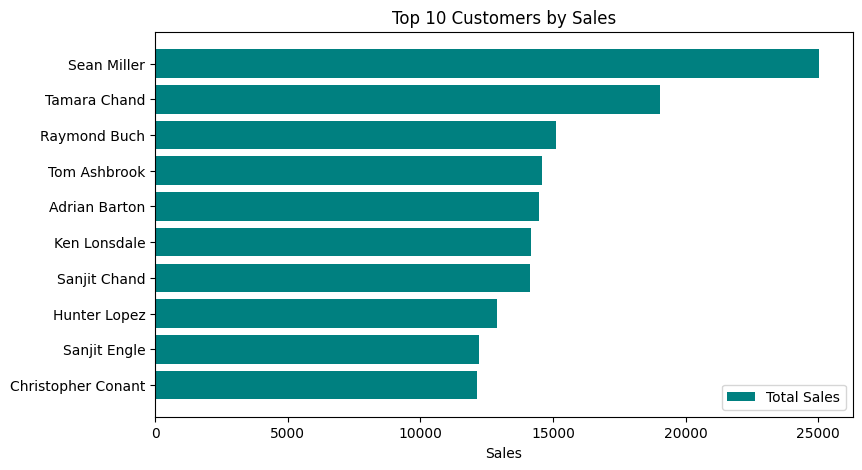

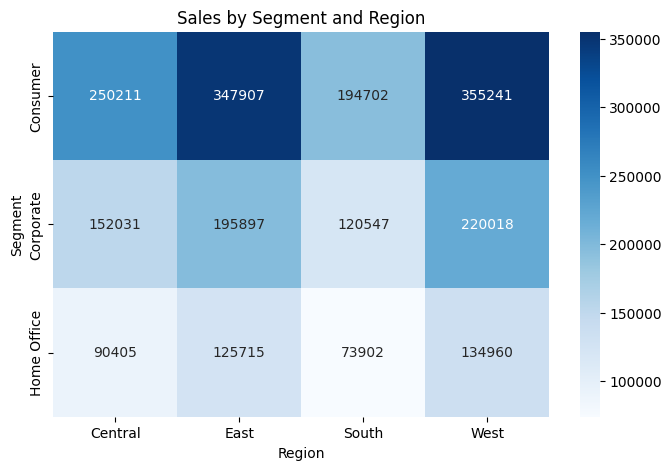

In [4]:
top10 = cust.sort_values("total_sales", ascending=False).head(10)
plt.figure(figsize=(9,5))
plt.barh(top10["Customer Name"], top10["total_sales"], color="teal", label="Total Sales")
plt.title("Top 10 Customers by Sales"); plt.xlabel("Sales"); plt.legend(); plt.gca().invert_yaxis(); plt.show()

plt.figure(figsize=(8,5))
sns.heatmap(pd.pivot_table(df, values="Sales", index="Segment", columns="Region", aggfunc="sum"), annot=True, fmt=".0f", cmap="Blues")
plt.title("Sales by Segment and Region"); plt.show()

Task 4: Customer Data Analysis

Findings
- Customers were grouped into Low, Medium and High value by total sales.
- The top 20% of customers generate a large share of total sales (see output).
- West and East regions have the most valuable customers.

Marketing Suggestions
- Loyalty rewards and early access for High-value customers.
- Holiday-season offers (Nov/Dec) since sales peak then.
- Targeted promotions in the South region to grow weak sales.
- Bundle deals on Phones, Chairs and Storage, the top sub-categories.